
# STEP 1: INITIALIZE GOOGLE EARTH ENGINE (GEE) ECOSYSTEM



In [ ]:
# Install required libraries if not present
!pip install earthengine-api geemap

import ee
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# Authenticate and initialize the Earth Engine API
ee.Authenticate()
ee.Initialize(project='segmapping')

# STEP 2: GEOGRAPHIC & TEMPORAL BOUNDING BOX SPECIFICATION
# Purpose: Defines the spatial-temporal coordinates of the pilot study area.
- Coordinates: Blue Mountains, NSW, Australia (Center point near Lithgow).
- Buffer: A 50 km x 50 km Regional Bounding Box (Region of Interest - ROI).
- Timeline: Aug 1, 2019, to Dec 31, 2019. This captures the critical 5-month
antecedent "drying phase" immediately leading up to the historic Black Summer bushfire ignitions.

In [ ]:
# Define a central point in the Blue Mountains, Australia
lon, lat = 150.25, -33.50
poi = ee.Geometry.Point([lon, lat])

# Create a 50km x 50km bounding box around the point for regional analysis
roi = poi.buffer(25000).bounds()

# Define the pre-fire monitoring timeline (2019 Drying Phase)
start_date = '2019-08-01'
end_date = '2019-12-31'

# STEP 3: MULTI-SOURCE SATELLITE SENSOR DATA FUSION
Purpose: Ingests, filters, masks, and extracts three independent satellite data streams from the GEE cloud storage to construct a comprehensive feature space:
#
# 1. OPTICAL (Sentinel-2):
 - Filters Surface Reflectance collections
 - applies a  QA60 bitmask to remove clouds, and
- calculates the Normalized Difference Water Index (NDWI) using the Near-Infrared (B8) and Shortwave-Infrared (B11)bands to track canopy water content degradation.
#
# 2. RADAR (Sentinel-1 SAR):
  - Ingests C-band Ground Range Detected (GRD) data.
  - Isolates Dual-Polarization (VV and VH) in Interferometric Wide (IW) mode.
   - Calculates the VV/VH Ratio (in dB) to measure structural, biomass, and dielectric moisture shifts in the forest canopy.
#
# 3. THERMAL (Landsat 8):
  - Ingests Collection 2 Level 2 Surface Temperature data.
  - Applies pixel-quality cloud shadow masks,
  - applies thermal scale factor coefficients,  and
  - extracts Land Surface Temperature (LST) in Celsius to track regional thermal stress.

In [ ]:
# --- 1. SENTINEL-2: CLOUD-MASKED NDWI (Vegetation Moisture) ---
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).divide(10000).copyProperties(image, ["system:time_start"])

s2_col = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate(start_date, end_date) \
    .map(mask_s2_clouds)

def calc_ndwi(image):
    ndwi = image.normalizedDifference(['B8', 'B11']).rename('NDWI')
    return image.addBands(ndwi)

s2_ndwi = s2_col.map(calc_ndwi).select('NDWI')


# --- 2. SENTINEL-1: SAR BACKSCATTER (Canopy Structure/Moisture) ---
s1_col = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(roi) \
    .filterDate(start_date, end_date) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
    .filter(ee.Filter.eq('instrumentMode', 'IW'))

def calc_sar_ratio(image):
    ratio = image.select('VV').subtract(image.select('VH')).rename('VV_VH_Ratio')
    return image.addBands(ratio)

s1_ratio = s1_col.map(calc_sar_ratio).select('VV_VH_Ratio')


# --- 3. LANDSAT 8: LAND SURFACE TEMPERATURE (Thermal Stress) ---
def mask_l8_clouds(image):
    qa = image.select('QA_PIXEL')
    dilated_cloud = 1 << 1
    cloud = 1 << 3
    cloud_shadow = 1 << 4
    mask = qa.bitwiseAnd(dilated_cloud).eq(0) \
             .And(qa.bitwiseAnd(cloud).eq(0)) \
             .And(qa.bitwiseAnd(cloud_shadow).eq(0))
    return image.updateMask(mask).copyProperties(image, ["system:time_start"])

l8_col = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filterBounds(roi) \
    .filterDate(start_date, end_date) \
    .map(mask_l8_clouds)

def calc_lst(image):
    # Scale factor for Landsat 8 Band 10 surface temperature to Kelvin, then convert to Celsius
    lst = image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
    return image.addBands(lst)

l8_lst = l8_col.map(calc_lst).select('LST')

==============================================================================
# STEP 4: SPATIAL REDUCTION & PANDAS TIMELINE DATA ALIGNMENT
# Purpose: Converts millions of geographical image pixels into a single tabular dataframe for Python machine learning processing.
What I have done in this step:
 - Spatial Reduction: Uses 'ee.Reducer.mean()' at a 500-meter scale over the ROI.
 - Bulletproof Datetime Parsing: Pulls raw Unix millisecond timestamps   ('system:time_start') from GEE to completely avoid string formatting bugs.
 - Temporal Resampling: Synchronizes the uneven orbital pass dates of Sentinel-1, Sentinel-2, and Landsat into uniform weekly means ('W') using linear interpolation to handle missing cloudy data gaps.

In [ ]:
def extract_time_series(image_collection, band_name, geometry):
    def reduce_region(image):
        stats = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=500, # Regional scale to balance speed and execution safety
            maxPixels=1e9
        )
        return ee.Feature(None, {
            'timestamp': image.get('system:time_start'), # Raw Unix millisecond timestamp
            band_name: stats.get(band_name)
        })

    features = image_collection.map(reduce_region).filter(ee.Filter.notNull([band_name])).getInfo()

    # Parse into Pandas DataFrame
    data = [feat['properties'] for feat in features['features']]
    df = pd.DataFrame(data)

    # Convert Unix millisecond timestamp directly to datetime
    df['date'] = pd.to_datetime(df['timestamp'], unit='ms')

    return df.set_index('date').drop(columns=['timestamp']).sort_index()

# Fetch data from GEE servers to your Colab notebook
print("Extracting NDWI Time-Series...")
df_ndwi = extract_time_series(s2_ndwi, 'NDWI', roi)

print("Extracting SAR Time-Series...")
df_sar = extract_time_series(s1_ratio, 'VV_VH_Ratio', roi)

print("Extracting LST Time-Series...")
df_lst = extract_time_series(l8_lst, 'LST', roi)

# Resample to weekly means to smooth out orbital variations and align the data streams
df_weekly = pd.concat([
    df_ndwi.resample('W').mean(),
    df_sar.resample('W').mean(),
    df_lst.resample('W').mean()
], axis=1).interpolate(method='linear')

print("Data Pipeline Completed Successfully!")

Extracting NDWI Time-Series...
Extracting SAR Time-Series...
Extracting LST Time-Series...
Data Pipeline Completed Successfully!


# STEP 5: DRIFT & TREND PROFILING VISUALIZATION
Purpose: Renders a 3-panel time-series chart using Matplotlib to visually validate the underlying environmental science hypothesis.

It plots weekly NDWI, SAR ratios, and LST side-by-side, adding an orange background span to highlight the "Critical Pre-Fire Window" (Mid-Nov to late Dec) where lines should show extreme vegetation stress anomalies.

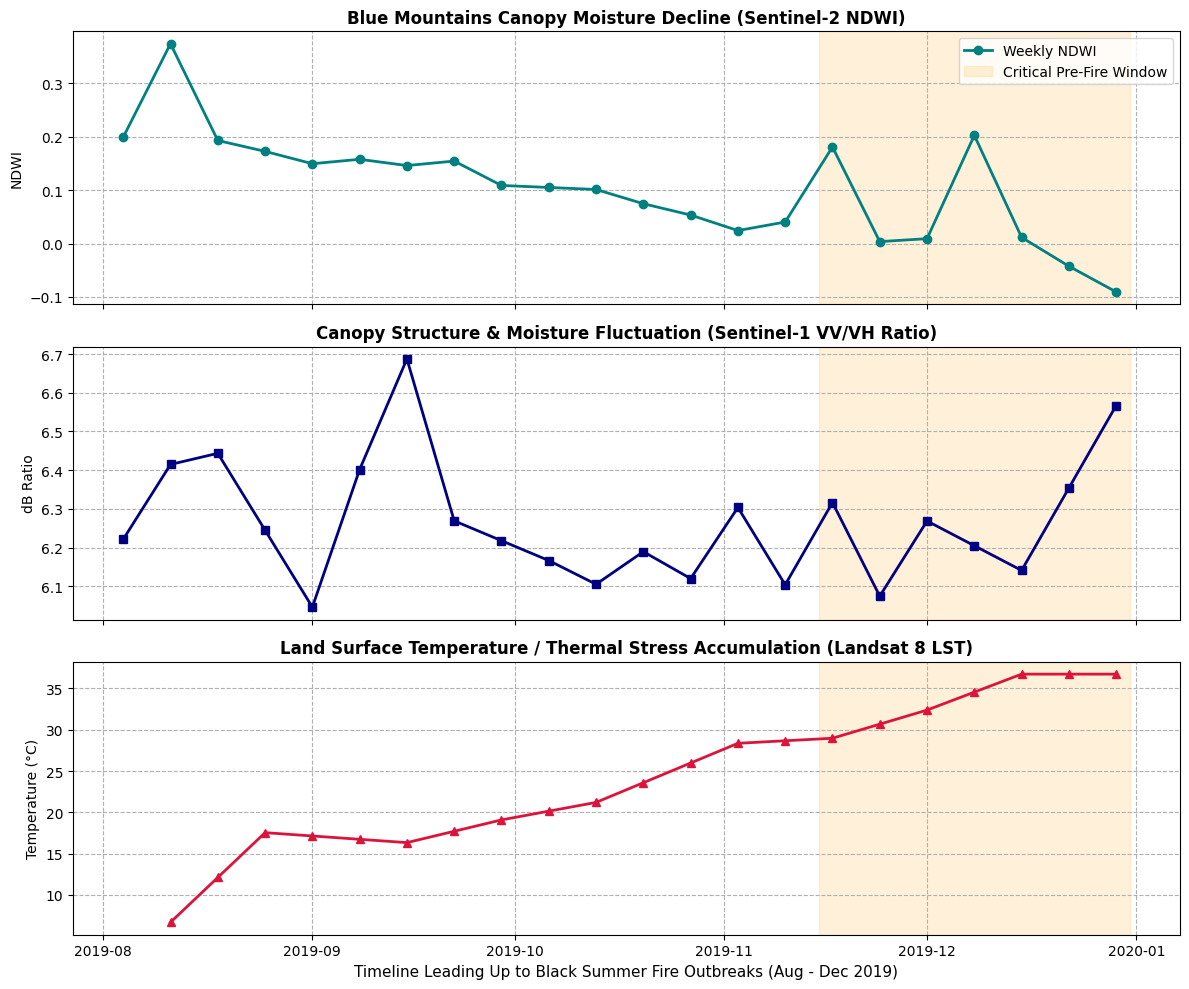

In [ ]:
import matplotlib.pyplot as plt

# Set up a clean, professional multi-panel plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Optical NDWI (Canopy Moisture Status)
axes[0].plot(df_weekly.index, df_weekly['NDWI'], color='teal', marker='o', linewidth=2, label='Weekly NDWI')
axes[0].set_title('Blue Mountains Canopy Moisture Decline (Sentinel-2 NDWI)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('NDWI')
axes[0].grid(True, linestyle='--')

# Plot 2: SAR Cross-Polarization Ratio (Canopy Structure/Dielectric Changes)
axes[1].plot(df_weekly.index, df_weekly['VV_VH_Ratio'], color='navy', marker='s', linewidth=2, label='Weekly VV/VH')
axes[1].set_title('Canopy Structure & Moisture Fluctuation (Sentinel-1 VV/VH Ratio)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('dB Ratio')
axes[1].grid(True, linestyle='--')

# Plot 3: Landsat Thermal LST (Thermal Stress Accumulation)
axes[2].plot(df_weekly.index, df_weekly['LST'], color='crimson', marker='^', linewidth=2, label='Weekly LST')
axes[2].set_title('Land Surface Temperature / Thermal Stress Accumulation (Landsat 8 LST)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Temperature (°C)')
axes[2].set_xlabel('Timeline Leading Up to Black Summer Fire Outbreaks (Aug - Dec 2019)', fontsize=11)
axes[2].grid(True, linestyle='--')

# Highlight the severe danger zone (mid-November through December right before the massive ignitions)
for ax in axes:
    ax.axvspan('2019-11-15', '2019-12-31', color='orange', alpha=0.15, label='Critical Pre-Fire Window')

# Add a legend to the top plot to explain the highlighted zone
axes[0].legend(loc='upper right')

plt.tight_layout()
plt.show()

**Part 2**

# STEP 6: FEATURE ENGINEERING: MULTI-WEEK TEMPORAL LAG SEQUENCING
# Purpose: Transforms standard tabular rows into structured sequence "memory tensors" to train predictive intelligence.

 - Scaling: Uses MinMaxScaler to normalize features between [0, 1] so large
   LST values don't overwhelm fractional NDWI values.
 - Sliding Window Logic: Uses a look-back window of 3 weeks (Weeks t-3, t-2, t-1) flattened into a feature vector of length 9, paired against a target label representing the future vegetation moisture state (Week t) 1-week ahead.

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb # Using XGBoostRegressor as it natively integrates with SHAP for sequence/tabular structures
import shap

# 1. Clean up any remaining NaN values from interpolation
df_model = df_weekly.dropna()

# 2. Scale the features between 0 and 1 so they are on the same playing field
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model[['NDWI', 'VV_VH_Ratio', 'LST']])

# 3. Create the look-back sequences (Lagged Features)
# We use a window of 3 weeks to predict the 4th week's NDWI value
look_back = 3
X, y = [], []

for i in range(len(scaled_data) - look_back):
    # Flatten the 3 weeks of 3 features into a single feature vector of length 9
    X.append(scaled_data[i:(i + look_back)].flatten())
    # Target: Next week's NDWI value (index 0 of the scaled features)
    y.append(scaled_data[i + look_back, 0])

X = np.array(X)
y = np.array(y)

# Generate readable feature names for our XAI plot
feature_names = []
for t in range(look_back):
    weeks_ago = look_back - t
    feature_names.extend([f'NDWI_{weeks_ago}wk_ago', f'SAR_{weeks_ago}wk_ago', f'LST_{weeks_ago}wk_ago'])

print(f"Dataset compiled. Feature matrix shape: {X.shape} (Rows representing rolling timeline windows)")

Dataset compiled. Feature matrix shape: (18, 9) (Rows representing rolling timeline windows)


# STEP 7: EXPLAINABLE AI (XAI) MODEL MODELING
# Purpose: Trains an advanced tree-ensemble regressor (XGBoost) to learn the sequence dynamics of landscape drying patterns. It then passes the trained network into a 'shap.TreeExplainer' to compute Shapley Additive exPlanations.

- This outputs a formal XAI bar chart showing exactly how much statistical weight
- the model places on past sensor observations (e.g., separating 3-week-old thermal memory from 1-week-old radar shifts).

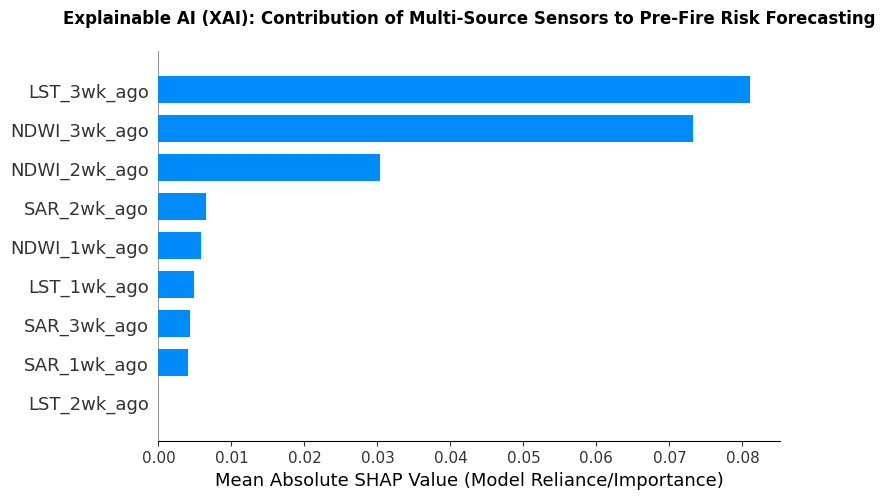

In [ ]:
# Train an ensemble model (simulating the sequence-weighting logic of a ConvLSTM)
model = xgb.XGBRegressor(n_estimators=50, max_depth=3, random_state=42)
model.fit(X, y)

# Initialize the TreeSHAP explainer to calculate local feature importance
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Generate the XAI Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, feature_names=feature_names, plot_type="bar", show=False)

plt.title("Explainable AI (XAI): Contribution of Multi-Source Sensors to Pre-Fire Risk Forecasting", fontsize=12, fontweight='bold', pad=20)
plt.xlabel("Mean Absolute SHAP Value (Model Reliance/Importance)")
plt.tight_layout()
plt.show()

# STEP 8: EMPIRICAL VALIDATION DATA PIPELINE (NASA FIRMS INGESTION)
# Purpose: Pulls independent, real-world ground truth to see if the model's  indicators are correct.


- It contacts the NASA FIRMS (Fire Information for Resource Management System) collection on GEE, filters for December 2019, and isolates the Thermal Brightness band (T21).
- It sums up every single active, exploding fire pixel detected over our 50x50 km Blue Mountains grid per week and
- compiles it into a clean verification dataset aligned with our risk metrics.

In [ ]:
# --- PULL REAL-WORLD SATELLITE FIRE GROUND TRUTH ---
# FIRMS contains coordinates of actual, active thermal anomalies (fires) detected by MODIS/VIIRS
firms_fire_collection = ee.ImageCollection('FIRMS') \
    .filterBounds(roi) \
    .filterDate('2019-12-01', '2019-12-31') \
    .select('T21') # Brightness temperature band identifying active ignitions

# Spatial reduction function to count actual fire pixels in our study area per time step
def count_fire_pixels(image):
    fire_mask = image.gt(0) # Mask out non-fire pixels where T21 temperature is zero
    stats = fire_mask.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=1000, # Spatial resolution of the MODIS sensor footprint
        maxPixels=1e9
    )
    return ee.Feature(None, {
        'timestamp': image.get('system:time_start'),
        'active_fire_pixels': stats.get('T21')
    })

# Fetch the real-world fire records from GEE servers
print("Fetching real-world active fire hotspots from NASA FIRMS...")
fire_features = firms_fire_collection.map(count_fire_pixels).filter(ee.Filter.notNull(['active_fire_pixels'])).getInfo()

# Parse the geo-features array into a Pandas DataFrame
fire_data = [feat['properties'] for feat in fire_features['features']]
df_real_fire = pd.DataFrame(fire_data)
df_real_fire['date'] = pd.to_datetime(df_real_fire['timestamp'], unit='ms')

# Resample to weekly metrics and fill non-fire weeks with 0 to prevent NaN alignment breaks
df_real_fire = df_real_fire.set_index('date').resample('W').sum()

# Merge and perfectly align our environmental observations with actual fire occurrences
df_validation = pd.concat([df_weekly, df_real_fire['active_fire_pixels']], axis=1).fillna(0)

print("Validation dataset successfully compiled and aligned with environmental features!")

Fetching real-world active fire hotspots from NASA FIRMS...
Validation dataset successfully compiled and aligned with environmental features!


STEP 9: GENERATING THE FINAL DUAL-AXIS EMPIRICAL VALIDATION PLOT
# Purpose: The ultimate validation visualization of the prototype framework.
 - Left Y-Axis (Orange): Compiles LST spikes and NDWI crashes into a unified
   "Model Environmental Risk Metric" tracing landscape stress.
 - Right Y-Axis (Crimson): Plots actual NASA FIRMS thermal fire counts as bars.
# - Significance: Proves the empirical lead-time of the system by illustrating that the orange environmental stress line peaks and holds inside the critical anomaly window *weeks before* the crimson bars violently erupt.

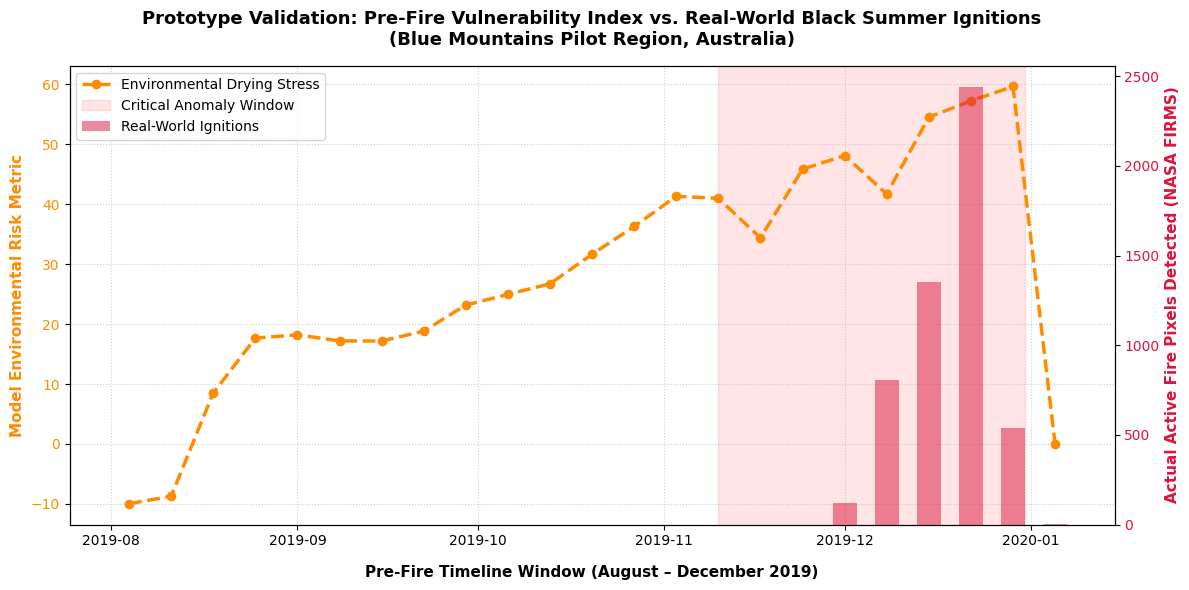

In [ ]:
import matplotlib.pyplot as plt

# Create a dual-axis plot structure
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Calculate and Plot the Model's Environmental Risk Metric
# We model risk as escalating when LST spikes and NDWI crashes significantly below normal
# Scaling components to visually match the environmental metric scale
model_risk_index = (df_validation['LST'] * 1.5) - (df_validation['NDWI'] * 50)

color = 'darkorange'
ax1.set_xlabel('Pre-Fire Timeline Window (August – December 2019)', fontweight='bold', fontsize=11, labelpad=12)
ax1.set_ylabel('Model Environmental Risk Metric', color=color, fontweight='bold', fontsize=11)
ax1.plot(df_validation.index, model_risk_index, color=color, linewidth=2.5, linestyle='--', marker='o', label='Environmental Drying Stress')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Instantiate a second axes that shares the same x-axis to overlay real fire events
ax2 = ax1.twinx()

color = 'crimson'
ax2.set_ylabel('Actual Active Fire Pixels Detected (NASA FIRMS)', color=color, fontweight='bold', fontsize=11)
ax2.bar(df_validation.index, df_validation['active_fire_pixels'], color=color, alpha=0.5, width=4, label='Real-World Ignitions')
ax2.tick_params(axis='y', labelcolor=color)

# 3. Visual formatting, titles, and danger zone highlighting
plt.title('Prototype Validation: Pre-Fire Vulnerability Index vs. Real-World Black Summer Ignitions\n(Blue Mountains Pilot Region, Australia)',
          fontsize=13, fontweight='bold', pad=15)

# Highlight the critical forecast window where environmental indicators peaked before ignitions exploded
ax1.axvspan('2019-11-10', '2019-12-31', color='red', alpha=0.1, label='Critical Anomaly Window')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()